In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/uciml/pima-indians-diabetes-database/diabetes.csv


In [3]:
df = pd.read_csv('/kaggle/input/datasets/organizations/uciml/pima-indians-diabetes-database/diabetes.csv')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [4]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nInfo:")
df.info()

print("\nTarget distribution:")
print(df["Outcome"].value_counts())
print(df["Outcome"].value_counts(normalize=True))

Shape: (768, 9)

Columns:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

Target distribution:
Outcome
0    500
1    268
Name: count, dtype: int64
Outcome


In [5]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [6]:
zero_counts = (df == 0).sum().sort_values(ascending=False)
zero_counts

Outcome                     500
Insulin                     374
SkinThickness               227
Pregnancies                 111
BloodPressure                35
BMI                          11
Glucose                       5
DiabetesPedigreeFunction      0
Age                           0
dtype: int64

In [7]:
zero_share = ((df == 0).mean() * 100).sort_values(ascending=False)
zero_share

Outcome                     65.104167
Insulin                     48.697917
SkinThickness               29.557292
Pregnancies                 14.453125
BloodPressure                4.557292
BMI                          1.432292
Glucose                      0.651042
DiabetesPedigreeFunction     0.000000
Age                          0.000000
dtype: float64

In [8]:
suspicious_zero_cols = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

df[suspicious_zero_cols].eq(0).sum()

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

Подозрительные нули
Glucose = 0
BloodPressure = 0
SkinThickness = 0
Insulin = 0
BMI = 0
Редактируем глюкозу,давление.

In [9]:
df.sort_values(by='BloodPressure', ascending=True).head(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
15,7,100,0,0,0,30.0,0.484,32,1
703,2,129,0,0,0,38.5,0.304,41,0
697,0,99,0,0,0,25.0,0.253,22,0
78,0,131,0,0,0,43.2,0.270,26,1
60,2,84,0,0,0,0.0,0.304,21,0


**смотрим, как изменится картина пропусков, если подозрительные нули считать NaN.**# 

In [10]:
suspicious_zero_cols = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
]

df_eda = df.copy()
df_eda[suspicious_zero_cols] = df_eda[suspicious_zero_cols].replace(0, np.nan)

df_eda.isna().sum().sort_values(ascending=False)

(df_eda.isna().mean() * 100).sort_values(ascending=False)

df_eda.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,763.0,121.686763,30.535641,44.000,99.00000,117.0000,141.00000,199.00
BloodPressure,733.0,72.405184,12.382158,24.000,64.00000,72.0000,80.00000,122.00
SkinThickness,541.0,29.153420,10.476982,7.000,22.00000,29.0000,36.00000,99.00
Insulin,394.0,155.548223,118.775855,14.000,76.25000,125.0000,190.00000,846.00
BMI,757.0,32.457464,6.924988,18.200,27.50000,32.3000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


Следующий шаг: сравним признаки по классам Outcome

Теперь нам нужно понять: отличаются ли пациенты с Outcome = 0 и Outcome = 1 по медианным значениям признаков.

In [11]:
df_eda.groupby("Outcome").median().T


Outcome,0,1
Pregnancies,2.000,4.000
Glucose,107.000,140.000
BloodPressure,70.000,74.500
SkinThickness,27.000,32.000
Insulin,102.500,169.500
BMI,30.100,34.300
DiabetesPedigreeFunction,0.336,0.449
Age,27.000,36.000


In [12]:
df_eda.groupby("Outcome").mean().T

Outcome,0,1
Pregnancies,3.298000,4.865672
Glucose,110.643863,142.319549
BloodPressure,70.877339,75.321429
SkinThickness,27.235457,33.000000
Insulin,130.287879,206.846154
BMI,30.859674,35.406767
DiabetesPedigreeFunction,0.429734,0.550500
Age,31.190000,37.067164


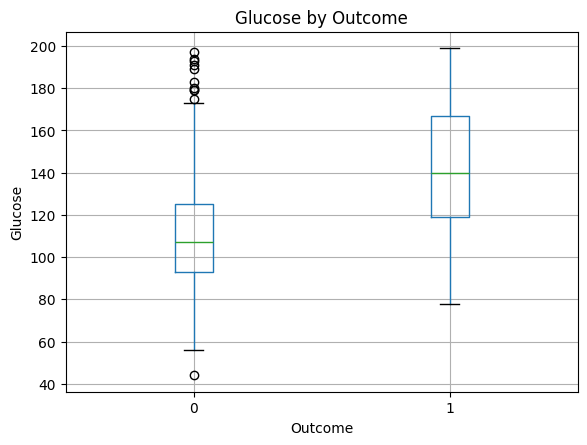

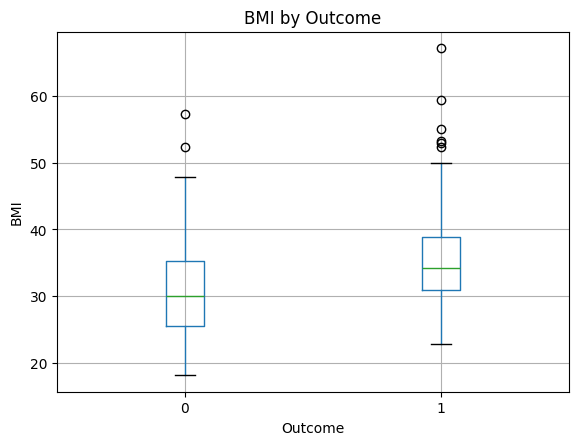

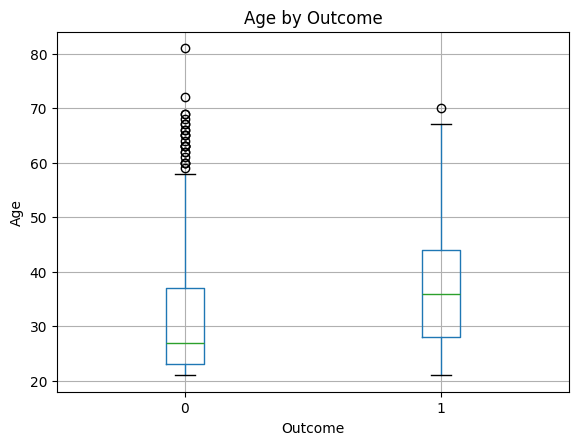

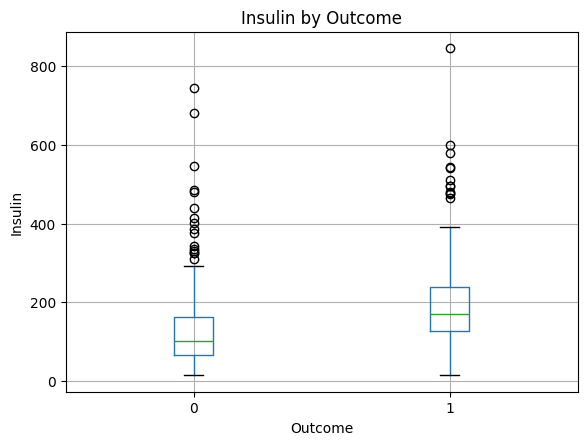

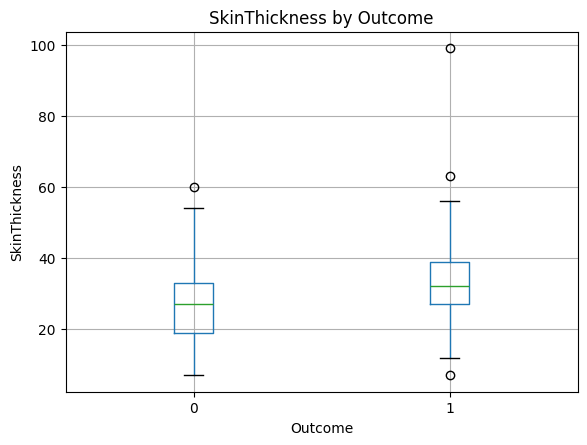

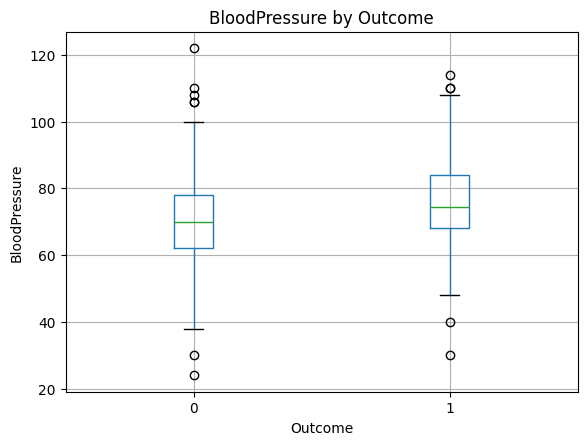

In [13]:
import matplotlib.pyplot as plt

selected_cols = [
    "Glucose",
    "BMI",
    "Age",
    "Insulin",
    "SkinThickness",
    "BloodPressure",
]

for col in selected_cols:
    df_eda.boxplot(column=col, by="Outcome")
    plt.title(f"{col} by Outcome")
    plt.suptitle("")
    plt.xlabel("Outcome")
    plt.ylabel(col)
    plt.show()

In [14]:
corr_with_target = (
    df_eda
    .corr(numeric_only=True)["Outcome"]
    .drop("Outcome")
    .sort_values(ascending=False)
)

corr_with_target

Glucose                     0.494650
BMI                         0.313680
Insulin                     0.303454
SkinThickness               0.259491
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
BloodPressure               0.170589
Name: Outcome, dtype: float64

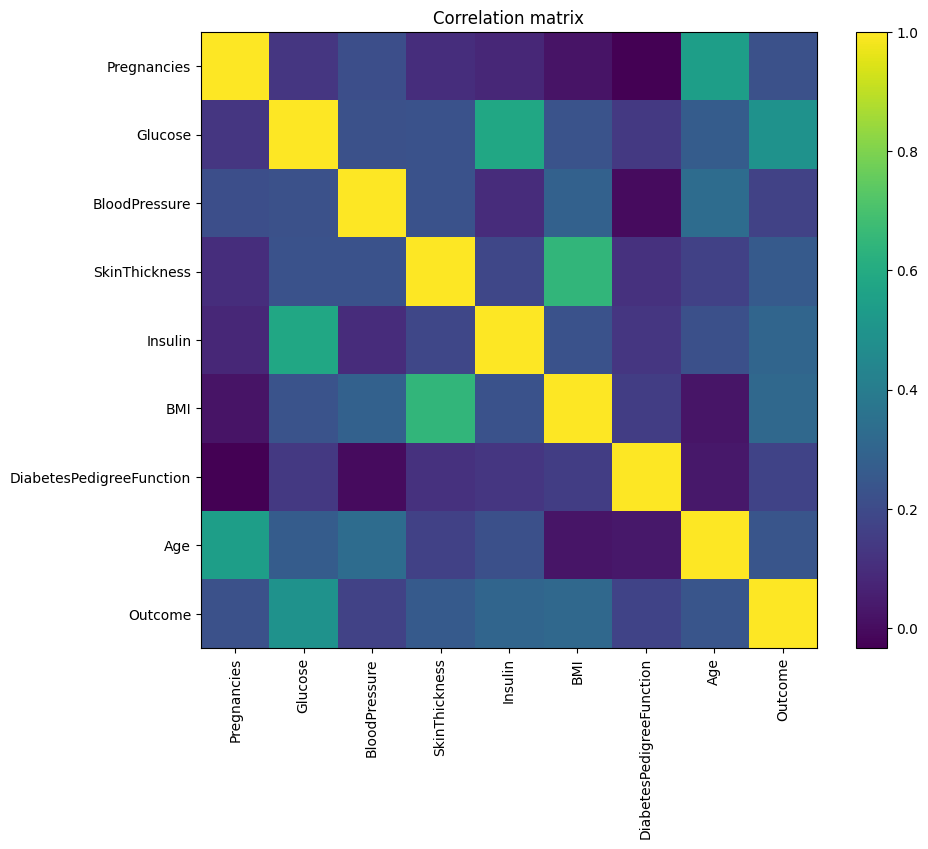

In [15]:
import matplotlib.pyplot as plt

corr_matrix = df_eda.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix)
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.colorbar()
plt.title("Correlation matrix")
plt.show()

1. Сначала строим простую честную baseline-схему.
2. Потом основную pipeline-версию со всеми признаками.
3. Потом делаем ablation study:
   - без indicators;
   - без Insulin;
   - без SkinThickness;
   - без Insulin + SkinThickness;
   - без Pregnancies.
4. Сравниваем не на test, а на validation / cross-validation.

Glucose: 0 → NaN → median imputation
BloodPressure: 0 → NaN → median imputation
BMI: 0 → NaN → median imputation
Insulin: 0 → NaN → median imputation + missing indicator
SkinThickness: 0 → NaN → median imputation + missing indicator

In [16]:
zero_indicator_cols = ["Insulin", "SkinThickness"]

for col in zero_indicator_cols:
    print(f"\n{col} zero indicator vs Outcome")
    indicator = (df[col] == 0).astype(int)
    print(pd.crosstab(indicator, df["Outcome"], normalize="index"))


Insulin zero indicator vs Outcome
Outcome         0         1
Insulin                    
0        0.670051  0.329949
1        0.631016  0.368984

SkinThickness zero indicator vs Outcome
Outcome               0         1
SkinThickness                    
0              0.667283  0.332717
1              0.612335  0.387665


## Missing indicators

We checked whether zero-like missing values in Insulin and SkinThickness are associated with the target.

For Insulin:
- Non-zero Insulin rows have Outcome = 1 in about 33.0% of cases.
- Zero Insulin rows have Outcome = 1 in about 36.9% of cases.

For SkinThickness:
- Non-zero SkinThickness rows have Outcome = 1 in about 33.3% of cases.
- Zero SkinThickness rows have Outcome = 1 in about 38.8% of cases.

Conclusion:
- The missingness indicators show a small association with Outcome.
- It is reasonable to test missing indicators for Insulin and SkinThickness in the preprocessing pipeline.

In [17]:
df_indicator_check = df.copy()

df_indicator_check["Insulin_missing"] = (df_indicator_check["Insulin"] == 0).astype(int)
df_indicator_check["SkinThickness_missing"] = (df_indicator_check["SkinThickness"] == 0).astype(int)

df_indicator_check.groupby("Outcome")[["Insulin_missing", "SkinThickness_missing"]].mean()

,Insulin_missing,SkinThickness_missing
Outcome,,
0,0.472000,0.278000
1,0.514925,0.328358


Glucose: 0 → NaN → median imputation
BloodPressure: 0 → NaN → median imputation
BMI: 0 → NaN → median imputation
Insulin: 0 → NaN → median imputation + missing indicator
SkinThickness: 0 → NaN → median imputation + missing indicator

We created binary indicators:
- Insulin_missing = 1 if Insulin equals 0
- SkinThickness_missing = 1 if SkinThickness equals 0

Missing-like values are slightly more frequent in Outcome = 1:

Insulin:
- Outcome = 0: 47.2%
- Outcome = 1: 51.5%

SkinThickness:
- Outcome = 0: 27.8%
- Outcome = 1: 32.8%

Conclusion:
- The association is not strong, but it is visible.
- We will test missing indicators for Insulin and SkinThickness in the preprocessing pipeline.

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df.nunique().sort_values()

Outcome                       2
Pregnancies                  17
BloodPressure                47
SkinThickness                51
Age                          52
Glucose                     136
Insulin                     186
BMI                         248
DiabetesPedigreeFunction    517
dtype: int64

## EDA summary

Task type:
- Binary classification.

Target:
- Outcome
- 0 = no diabetes
- 1 = diabetes

Dataset shape:
- 768 rows
- 9 columns
- 8 features + 1 target

Class distribution:
- Outcome = 0: 500 rows, about 65.1%
- Outcome = 1: 268 rows, about 34.9%

Initial data quality notes:
- No explicit missing values according to df.info().
- No full duplicate rows.
- All features are numerical.
- No categorical features found.

Suspicious zero values:
- Glucose: 5 zeros
- BloodPressure: 35 zeros
- SkinThickness: 227 zeros
- Insulin: 374 zeros
- BMI: 11 zeros

Preliminary preprocessing strategy:
- Treat suspicious zeros in Glucose, BloodPressure, SkinThickness, Insulin and BMI as missing values.
- Replace suspicious zeros with NaN inside preprocessing.
- Use median imputation.
- Test missing indicators for Insulin and SkinThickness.
- Keep all features in the first model version.
- Later compare variants without Insulin, without SkinThickness, and without both.

Important leakage rule:
- Imputer, scaler and model must be fitted only on training data.
- The test set should not be used for selecting preprocessing choices or hyperparameters.